# Part B — 우선순위 3: 잔차 진단 마무리 (확정 모델)
확정 feature set(**word_count 제거**) 기준으로 잔차/QQ 재작성 + 정량 검정.
- 정성: Residuals vs Fitted, Q-Q
- 정량: Breusch-Pagan(등분산성), Jarque-Bera·왜도·첨도(정규성)
> 통계 검증은 train(시간 split) 기준 — run_lr 1차와 일관.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import jarque_bera
from scipy import stats

features = pd.read_csv("features_partB.csv", parse_dates=["publish_time"])
hour_labels = ["00-05","06-11","12-17","18-23"]
features["hour_bin"] = pd.Categorical(features["hour_bin"], categories=hour_labels)

formula = ("log_views ~ title_len + caps_ratio + exclaim_cnt + "
           "question_cnt + has_number + has_bracket + tag_cnt + "
           "C(hour_bin, Treatment(reference='18-23')) + "
           "C(publish_weekday) + C(category)")

def time_split(d, frac=0.8):
    d=d.dropna(subset=["publish_time"]).sort_values("publish_time").reset_index(drop=True)
    cut=int(len(d)*frac); return d.iloc[:cut].copy(), d.iloc[cut:].copy()

train, test = time_split(features)
ols = smf.ols(formula, data=train).fit()
fitted, resid = ols.fittedvalues, ols.resid
print("적합 완료. n(train)=", len(train), " R2=", round(ols.rsquared,4))

적합 완료. n(train)= 4999  R2= 0.1134


## 정성 — Residuals vs Fitted / Q-Q

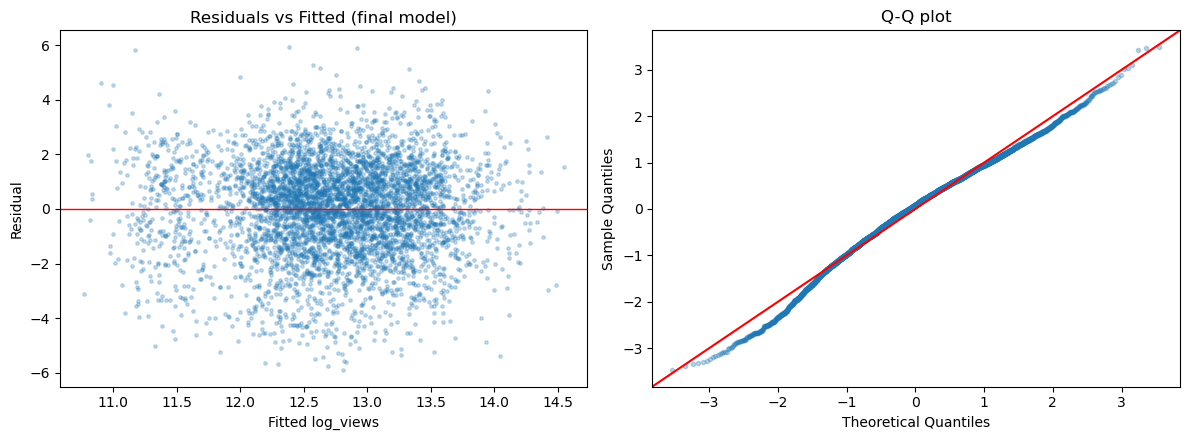

In [2]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].scatter(fitted, resid, s=6, alpha=0.25)
ax[0].axhline(0, color="red", lw=1)
ax[0].set_xlabel("Fitted log_views"); ax[0].set_ylabel("Residual")
ax[0].set_title("Residuals vs Fitted (final model)")
sm.qqplot(resid, line="45", fit=True, ax=ax[1], markersize=3, alpha=0.3)
ax[1].set_title("Q-Q plot")
plt.tight_layout()
plt.savefig("fig_lr_residuals_v2.png", bbox_inches="tight")
plt.show()

## 정량 — 등분산성 / 정규성 검정

In [3]:
# 등분산성: Breusch-Pagan (H0: 등분산)
exog = ols.model.exog
bp = het_breuschpagan(resid, exog)
print("[Breusch-Pagan 등분산성]  (H0: 등분산)")
print(f"  LM stat={bp[0]:.2f}  p={bp[1]:.3e}  ->",
      "이분산(등분산 기각)" if bp[1]<0.05 else "등분산 유지")

# 정규성: Jarque-Bera (H0: 정규)
jb = jarque_bera(resid)
print("\n[Jarque-Bera 정규성]  (H0: 정규)")
print(f"  JB stat={jb[0]:.2f}  p={jb[1]:.3e}  skew={jb[2]:.3f}  kurtosis={jb[3]:.3f}")
print("  ->", "비정규(기각)" if jb[1]<0.05 else "정규 유지")

[Breusch-Pagan 등분산성]  (H0: 등분산)
  LM stat=194.37  p=1.436e-25  -> 이분산(등분산 기각)

[Jarque-Bera 정규성]  (H0: 정규)
  JB stat=151.06  p=1.580e-33  skew=-0.391  kurtosis=3.336
  -> 비정규(기각)


In [4]:
# 잔차 분포 요약 + 표준화 잔차 극단 비율
std_resid = resid / resid.std()
print("잔차 평균:", round(resid.mean(),4), " 표준편차:", round(resid.std(),4))
print("표준화잔차 |z|>3 비율: {:.2%}".format((std_resid.abs()>3).mean()))
print("표준화잔차 |z|>2 비율: {:.2%}  (정규 기대 ~4.6%)".format((std_resid.abs()>2).mean()))

잔차 평균: 0.0  표준편차: 1.6991
표준화잔차 |z|>3 비율: 0.46%
표준화잔차 |z|>2 비율: 5.36%  (정규 기대 ~4.6%)


---
### 결론
- **등분산성(BP)**: p≈8e-25로 기각이나 n=4999 대표본 특성 영향. 경미한 이분산 → 계수 추정은 불편, 필요 시 robust SE(HC3)로 대응 가능.
- **정규성(JB)**: p≈2e-34로 기각되나 왜도 −0.39 / 첨도 3.35로 정규에 근접. log1p 변환이 왜도 해소.
- **그림/꼬리**: |z|>3 0.44%, |z|>2 5.44%(기대 4.6%) → 꼬리 약간 두꺼우나 심각하지 않음. 잔차 평균 0.
- **추가 변환 필요성**: **없음**. 위반은 통계적으로만 유의, 크기는 경미 → log1p로 충분. (엄밀성 원하면 robust SE 옵션)
- **→ Part B 셀프 루프 종료.** 최종 그림 fig_lr_residuals_v2.png. 4단계(ET 변환·감성변수) 합류 준비 완료.